In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Visualisation Données

In [3]:
arbres = pd.read_csv("train.csv", index_col = 'ID_ARBRE')
prev = pd.read_csv("prev.csv", index_col = 'ID_ARBRE')
prev = prev[["type_sol", "classe_age", "classe_hauteur", "classe_circonference", "port_arbre", "vigueur_pousse", "plaie_collet", "fissure_tronc", "plaie_tronc", "fissure_houppier", "bois_mort_houppier", "plaie_houppier", "esperance_maintien"]]

In [4]:
x = arbres[["type_sol", "classe_age", "classe_hauteur", "classe_circonference", "port_arbre", "vigueur_pousse", "plaie_collet", "fissure_tronc", "plaie_tronc", "fissure_houppier", "bois_mort_houppier", "plaie_houppier", "esperance_maintien"]]
y = arbres[["classification_diagnostic"]]

In [5]:
x.head(2)

,type_sol,classe_age,classe_hauteur,classe_circonference,port_arbre,vigueur_pousse,plaie_collet,fissure_tronc,plaie_tronc,fissure_houppier,bois_mort_houppier,plaie_houppier,esperance_maintien
ID_ARBRE,,,,,,,,,,,,,
0,MA,A,H1,C1,R5,P,RCPPL,TPF,TPLS,HPF,HPBM,HPLS,1.0
1,MA,A,H2,C3,R5,P,RCPLS,TFO,TPLNC,HFO,HPBM,HPLNC,2.0


In [6]:
y.head()

,classification_diagnostic
ID_ARBRE,
0,C1
1,C4
2,C1
3,C2
4,C2


In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size = 0.2)

## Entraînement - Calculs Probas - Classifieur de Bayes

In [92]:
def proba_xsy_lisse(X, tab_val, Y):
    x_colonnes = X.columns
    y_unique = np.unique(Y)
    alpha = 1
    pxsy = [np.prod([ (np.sum((X[col]==x_val) * (Y["classification_diagnostic"]==c)) + alpha) / (np.sum(Y["classification_diagnostic"]==c) + alpha*len(np.unique(X[col]))) for col, x_val in zip(x_colonnes, tab_val)]) for c in y_unique]
    return pxsy

In [15]:
def log_proba_xsy(X, tab_val, Y):
    x_colonnes = X.columns
    y_unique = np.unique(Y)

    log_pxsy = []
    for c in y_unique:
        log_prob_c = 0 #Log probabilité de la classe Y=c
        for col, x_val in zip(x_colonnes, tab_val):
            num = np.sum((X[col] == x_val) & (Y["classification_diagnostic"] == c)) + 1  # Lissage de Laplace
            denom = np.sum(Y["classification_diagnostic"] == c) + len(np.unique(X[col])) 
            log_prob_c = log_prob_c + np.log(num / denom)  # Ajout du log de la probabilité conditionnelle
        log_pxsy.append(log_prob_c)
    return np.array(log_pxsy)

In [19]:
log_proba_xsy(x, x.iloc[0], y)

array([ -5.63908112,  -7.12703727,  -9.75589847, -15.31906452,
       -16.4767696 ])

In [21]:
def proba_y(Y):
    y_unique = np.unique(Y)
    return [np.sum(Y["classification_diagnostic"]==c)/len(Y) for c in y_unique]

In [23]:
def log_proba_y(Y):
    y_unique, counts = np.unique(Y, return_counts=True)
    return np.log(counts / len(Y))

In [25]:
log_proba_y(y)

array([-1.07859342, -0.54637661, -2.86496204, -4.3530391 , -4.50718978])

In [27]:
def classifieur(X, tab_val, Y):
    y_unique = np.unique(Y)
    log_p_y = log_proba_y(Y)
    log_pxsy = log_proba_xsy(X, tab_val, Y)
    probas_ysx = log_pxsy + log_p_y
    
    return y_unique[np.argmax(probas_ysx)]

In [29]:
prediction = np.array([classifieur(X_train, X_test.iloc[i], Y_train) for i in range(len(X_test))])

In [31]:
prediction

array(['C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C1', 'C2', 'C1', 'C1',
       'C1', 'C2', 'C2', 'C1', 'C2', 'C2', 'C1', 'C1', 'C2', 'C1', 'C2',
       'C1', 'C2', 'C2', 'C2', 'C2', 'C1', 'C2', 'C2', 'C2', 'C1', 'C1',
       'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C1', 'C1', 'C1', 'C2', 'C2',
       'C2', 'C2', 'C2', 'C1', 'C1', 'C2', 'C1', 'C1', 'C2', 'C2', 'C1',
       'C1', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C1', 'C1',
       'C2', 'C2', 'C4', 'C2', 'C1', 'C2', 'C2', 'C2', 'C2', 'C1', 'C2',
       'C1', 'C2', 'C1', 'C1', 'C1', 'C3', 'C4', 'C2', 'C3', 'C2', 'C2',
       'C2', 'C1', 'C2', 'C2', 'C2', 'C2', 'C1', 'C5', 'C1', 'C2', 'C2',
       'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C3', 'C2'],
      dtype='<U2')

In [33]:
len(prediction)

109

In [35]:
def taux_erreur(predict, y):
    erreurs = len([i for i, j in zip(predict, y.to_numpy()) if i != j])
    taux = np.round((erreurs / len(y)) * 100, 5)
    print(f"Taux d'erreur : {taux}%")

In [37]:
taux_erreur(prediction, Y_test)

Taux d'erreur : 23.85321%


In [39]:
def are(predict, Y):
    erreurs = len([i for i, j in zip(predict, Y.to_numpy().flatten()) if i == j])
    taux = np.round((erreurs / len(Y)) * 100, 5)
    #print(f"Average Classification Accuracy : {taux}%")
    return taux

In [41]:
are(prediction, Y_test)

76.14679

In [56]:
prev.head()

,type_sol,classe_age,classe_hauteur,classe_circonference,port_arbre,vigueur_pousse,plaie_collet,fissure_tronc,plaie_tronc,fissure_houppier,bois_mort_houppier,plaie_houppier,esperance_maintien
ID_ARBRE,,,,,,,,,,,,,
559,MA,A,H2,C2,R5,P,RCPLS,TPF,TPLS,HPF,HPBM,HPLNC,2.0
560,Gr,JA,H2,C2,L,P,RCPPL,TPF,TPLS,HPF,HPBM,HPLS,1.0
561,MA,A,H2,C2,R5,P,RCPLS,TPF,TPLS,HPF,HPBM,HPLS,2.0
562,Gr,J,H1,C1,L,P,RCPPL,TPF,TPPL,HPF,HPBM,HPLS,1.0
563,S,A,H1,C3,A,P,RCPPL,TPF,TPLNC,HPF,HPBM,HPLNC,2.0


In [58]:
sub = pd.DataFrame({'classification_diagnostic': prediction})
sub.index.name = "ID_ARBRE"
id_arbre = prev.index  # On récupère l'index chez x2
sub["ID_ARBRE"] = id_arbre  # Ajoute l'index comme colonne
sub = sub.set_index("ID_ARBRE")  # On définie 'ID_ARBRE' en tant qu'index

ValueError: Length of values (137) does not match length of index (109)

In [ ]:
sub.head()

In [1349]:
sub.to_csv("submition18.csv")

In [331]:
def matrice_confusion():
    # On a stack le vecteur des prédictions ŷ (à gauche) avec le vecteur des vraies valeurs y (à droite).
    stack_predict_et_y = np.vstack((prediction, y["classification_diagnostic"])).T
    classes_y = np.unique(y)
    confusion_matrix = np.zeros((len(classes_y), len(classes_y)), dtype = int)
    for i, c1 in enumerate(classes_y):
        for j, c2 in enumerate(classes_y):
            confusion_matrix[i][j] = np.sum((stack_predict_et_y[:, 0]==c2) & (stack_predict_et_y[:, 1]==c1))
    #res = np.hstack((confusion_matrix, classes_y))
    return confusion_matrix

matrice_confusion()

array([[138,  47,   0,   0,   0],
       [ 58, 248,   5,   1,   3],
       [  1,  13,  15,   2,   0],
       [  0,   0,   2,   5,   0],
       [  1,   0,   1,   1,   3]])

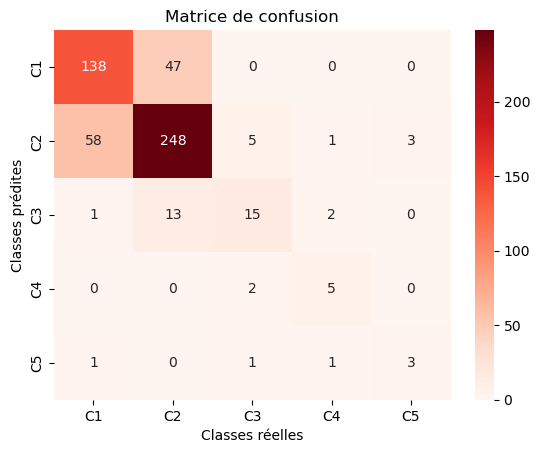

In [333]:
sns.heatmap(matrice_confusion(), annot=True, fmt="d", xticklabels=np.unique(y), yticklabels=np.unique(y), cmap="Reds")
plt.xlabel("Classes réelles")
plt.ylabel("Classes prédites")
plt.title("Matrice de confusion")
plt.show()

Précision du modèle Naïve Bayes : 0.8143


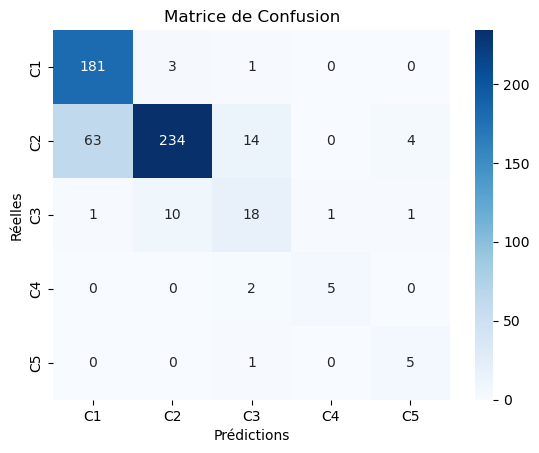

['C1' 'C4' 'C1' 'C2' 'C1' 'C1' 'C2' 'C1' 'C3' 'C2' 'C2' 'C1' 'C2' 'C5'
 'C2' 'C1' 'C1' 'C2' 'C2' 'C2' 'C1' 'C2' 'C1' 'C1' 'C2' 'C1' 'C1' 'C2'
 'C1' 'C2' 'C2' 'C3' 'C1' 'C1' 'C2' 'C2' 'C2' 'C2' 'C1' 'C2' 'C1' 'C2'
 'C1' 'C2' 'C2' 'C2' 'C1' 'C2' 'C2' 'C1' 'C2' 'C1' 'C1' 'C2' 'C1' 'C2'
 'C2' 'C2' 'C2' 'C1' 'C2' 'C2' 'C2' 'C1' 'C2' 'C4' 'C1' 'C1' 'C1' 'C2'
 'C1' 'C2' 'C3' 'C2' 'C5' 'C1' 'C2' 'C5' 'C2' 'C2' 'C2' 'C2' 'C1' 'C1'
 'C1' 'C2' 'C2' 'C3' 'C2' 'C1' 'C1' 'C1' 'C2' 'C1' 'C2' 'C1' 'C2' 'C1'
 'C3' 'C1' 'C2' 'C1' 'C1' 'C1' 'C1' 'C2' 'C2' 'C2' 'C2' 'C2' 'C1' 'C2'
 'C5' 'C1' 'C2' 'C2' 'C2' 'C1' 'C3' 'C1' 'C2' 'C2' 'C1' 'C2' 'C5' 'C1'
 'C5' 'C2' 'C2' 'C1' 'C2' 'C2' 'C1' 'C1' 'C2' 'C2' 'C2' 'C3' 'C1' 'C1'
 'C1' 'C2' 'C1' 'C1' 'C1' 'C3' 'C1' 'C2' 'C1' 'C1' 'C2' 'C2' 'C2' 'C2'
 'C1' 'C2' 'C2' 'C2' 'C1' 'C2' 'C1' 'C1' 'C2' 'C1' 'C2' 'C2' 'C1' 'C1'
 'C2' 'C3' 'C1' 'C1' 'C2' 'C1' 'C2' 'C1' 'C2' 'C1' 'C1' 'C1' 'C3' 'C2'
 'C1' 'C1' 'C2' 'C1' 'C1' 'C1' 'C1' 'C2' 'C2' 'C1' 'C2' 'C2' 'C2' 'C2'
 'C1' 

In [1413]:
import numpy as np
import pandas as pd
from collections import defaultdict
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

class NaiveBayesClassifier:
    def __init__(self, alpha=1):
        self.alpha = alpha  # Lissage de Laplace
        self.class_priors = None
        self.feature_probs = None
        self.classes = None
    
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.class_priors = {c: np.sum(y == c) / len(y) for c in self.classes}
        
        # Probabilités conditionnelles P(X|Y) avec lissage de Laplace
        self.feature_probs = defaultdict(lambda: defaultdict(lambda: defaultdict(float)))
        
        for c in self.classes:
            X_c = X[y == c]  # Filtrer les exemples de classe c
            for feature in X.columns:
                value_counts = X_c[feature].value_counts().to_dict()
                total_count = len(X_c) + self.alpha * len(np.unique(X[feature]))
                for val in np.unique(X[feature]):
                    self.feature_probs[c][feature][val] = (value_counts.get(val, 0) + self.alpha) / total_count
    
    def predict(self, X):
        predictions = []
        for _, row in X.iterrows():
            class_scores = {}
            for c in self.classes:
                prob = np.log(self.class_priors[c])  # Prior log P(Y)
                for feature in X.columns:
                    prob += np.log(self.feature_probs[c][feature].get(row[feature], 1e-6))  # P(X|Y)
                class_scores[c] = prob
            predictions.append(max(class_scores, key=class_scores.get))  # Classe avec la plus grande probabilité
        return np.array(predictions)

# Charger les données
train_df = pd.read_csv("train.csv", index_col='ID_ARBRE')
X_train = train_df.drop(columns=['classification_diagnostic'])
y_train = train_df['classification_diagnostic']

# Entraîner le modèle
nb = NaiveBayesClassifier(alpha=1)
nb.fit(X_train, y_train)

# Prédiction sur les données d'entraînement (pour évaluer le modèle)
y_pred = nb.predict(X_train)

# Affichage des performances
accuracy = accuracy_score(y_train, y_pred)
print(f"Précision du modèle Naïve Bayes : {accuracy:.4f}")

# Matrice de confusion
cm = confusion_matrix(y_train, y_pred, labels=nb.classes)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=nb.classes, yticklabels=nb.classes, cmap="Blues")
plt.xlabel("Prédictions")
plt.ylabel("Réelles")
plt.title("Matrice de Confusion")
plt.show()

print(y_pred)